# Colab baseline v1

本 notebook 只做一件事：
- 重新建立 Colab 环境
- 跑一轮干净的 MAPPO baseline on VMAS/navigation
- 列出 outputs
- 用 metrics_summary.py 汇总结果


## 1. Clone repo

In [1]:
!git clone https://github.com/WonderfulClaire/low_altitude_marl.git
%cd /content/low_altitude_marl
!ls

Cloning into 'low_altitude_marl'...
remote: Enumerating objects: 111, done.
remote: Counting objects: 100% (111/111), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 111 (delta 43), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (111/111), 95.10 KiB | 1.22 MiB/s, done.
Resolving deltas: 100% (43/43), done.
/content/low_altitude_marl
notebooks  README.md  requirements.txt	src


## 2. Install dependencies

In [2]:
%cd /content/low_altitude_marl
!python -m pip install --upgrade pip
!python -m pip install -r requirements.txt

/content/low_altitude_marl
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 9.5 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 25.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 55.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 96.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 78.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 74.4 MB/s  0:00:00
  Created wheel for vmas: filename=vmas-1.5.2-py3-none-any.whl size=260328 sha256=3b0b4f99ee0a9d6afee00817cbda

## 3. Check torch and GPU

In [3]:
import torch
print('torch version:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
print('gpu count:', torch.cuda.device_count())
if torch.cuda.is_available():
    print('gpu name:', torch.cuda.get_device_name(0))

torch version: 2.10.0+cpu
cuda available: False
gpu count: 0


## 4. Run MAPPO baseline (short run)

In [4]:
%cd /content/low_altitude_marl
import os
os.environ['WANDB_MODE'] = 'disabled'

!python -m benchmarl.run \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=60000 \
  seed=0

/content/low_altitude_marl

Algorithm: mappo, Task: vmas/navigation

Loaded config:

experiment:
  sampling_device: cpu
  train_device: cpu
  buffer_device: cpu
  share_policy_params: true
  prefer_continuous_actions: true
  collect_with_grad: false
  parallel_collection: false
  gamma: 0.99
  lr: 5.0e-05
  adam_eps: 1.0e-06
  adam_extra_kwargs: {}
  clip_grad_norm: true
  clip_grad_val: 5.0
  soft_target_update: true
  polyak_tau: 0.005
  hard_target_update_frequency: 5
  exploration_eps_init: 0.8
  exploration_eps_end: 0.01
  exploration_anneal_frames: null
  max_n_iters: null
  max_n_frames: 60000
  on_policy_collected_frames_per_batch: 6000
  on_policy_n_envs_per_worker: 10
  on_policy_n_minibatch_iters: 45
  on_policy_minibatch_size: 400
  off_policy_collected_frames_per_batch: 6000
  off_policy_n_envs_per_worker: 10
  off_policy_n_optimizer_steps: 1000
  off_policy_train_batch_size: 128
  off_policy_memory_size: 1000000
  off_policy_init_random_frames: 0
  off_policy_use_prioriti

## 5. List outputs

In [5]:
%cd /content/low_altitude_marl
!find outputs -maxdepth 3 -type d | sort

/content/low_altitude_marl
outputs
outputs/2026-04-03
outputs/2026-04-03/01-40-47
outputs/2026-04-03/01-40-47/.hydra
outputs/2026-04-03/01-40-47/mappo_navigation_mlp__f150b0c1_26_04_03-01_40_47


## 6. Summarize latest run
把下面 `RUN_ROOT` 改成上一个 cell 里最新生成的时间目录。

In [8]:
%cd /content/low_altitude_marl
RUN_ROOT = '/content/low_altitude_marl/outputs/2026-04-03/01-40-47'
!python src/metrics_summary.py "$RUN_ROOT"

/content/low_altitude_marl
Run root: /content/low_altitude_marl/outputs/2026-04-03/01-40-47

=== collection_reward_episode_reward_mean.csv ===
   step     value
0     0 -0.442668
1     1 -0.315566
2     2 -0.183335
3     3 -0.027397
4     4  0.463985
...
   step     value
5     5  0.526555
6     6  0.686009
7     7  0.852464
8     8  0.759503
9     9  0.852175
last value: 0.8521748185157776

=== collection_reward_reward_mean.csv ===
   step     value
0     0 -0.004427
1     1 -0.003156
2     2 -0.001833
3     3 -0.000274
4     4  0.004640
...
   step     value
5     5  0.005266
6     6  0.006860
7     7  0.008527
8     8  0.007598
9     9  0.008587
last value: 0.0085866954177618

=== train_agents_loss_critic.csv ===
   step     value
0     0  0.052233
1     1  0.065900
2     2  0.074620
3     3  0.069300
4     4  0.018173
...
   step     value
5     5  0.021184
6     6  0.007319
7     7  0.006124
8     8  0.017554
9     9  0.009418
last value: 0.0094180209562182

=== train_agents_loss_

## 7. Optional: quick plot of episode_reward_mean

target: /content/low_altitude_marl/outputs/2026-04-03/01-40-47/mappo_navigation_mlp__f150b0c1_26_04_03-01_40_47/mappo_navigation_mlp__f150b0c1_26_04_03-01_40_47/scalars/collection_reward_episode_reward_mean.csv


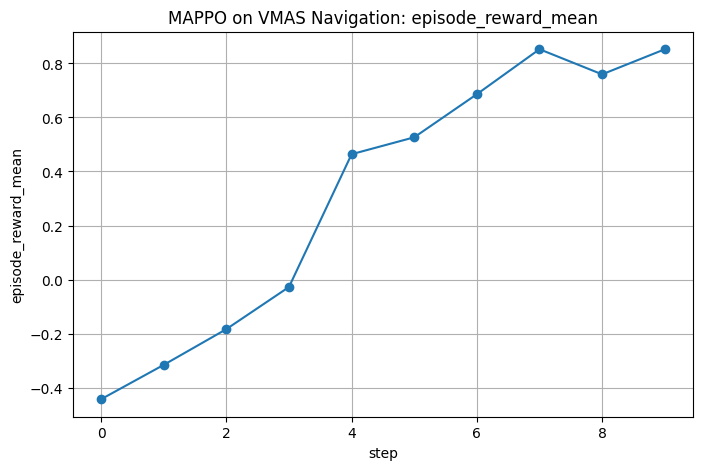

In [9]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

root = Path(RUN_ROOT)
target = None
for p in root.rglob('collection_reward_episode_reward_mean.csv'):
    target = p
    break
print('target:', target)
df = pd.read_csv(target, header=None, names=['step', 'value'])
plt.figure(figsize=(8,5))
plt.plot(df['step'], df['value'], marker='o')
plt.xlabel('step')
plt.ylabel('episode_reward_mean')
plt.title('MAPPO on VMAS Navigation: episode_reward_mean')
plt.grid(True)
plt.show()